Carregando UNSW-NB15 de: ..\..\data\raw\UNSW-NB15\UNSW_NB15_training-set.csv
Carregando Lab Dataset de: ..\..\data\processed\ubuntu_server_dataset_final_argus.csv
Analisando as seguintes features comuns: ['sttl', 'dttl', 'sload', 'dload', 'rate', 'ct_state_ttl', 'smean', 'dmean']


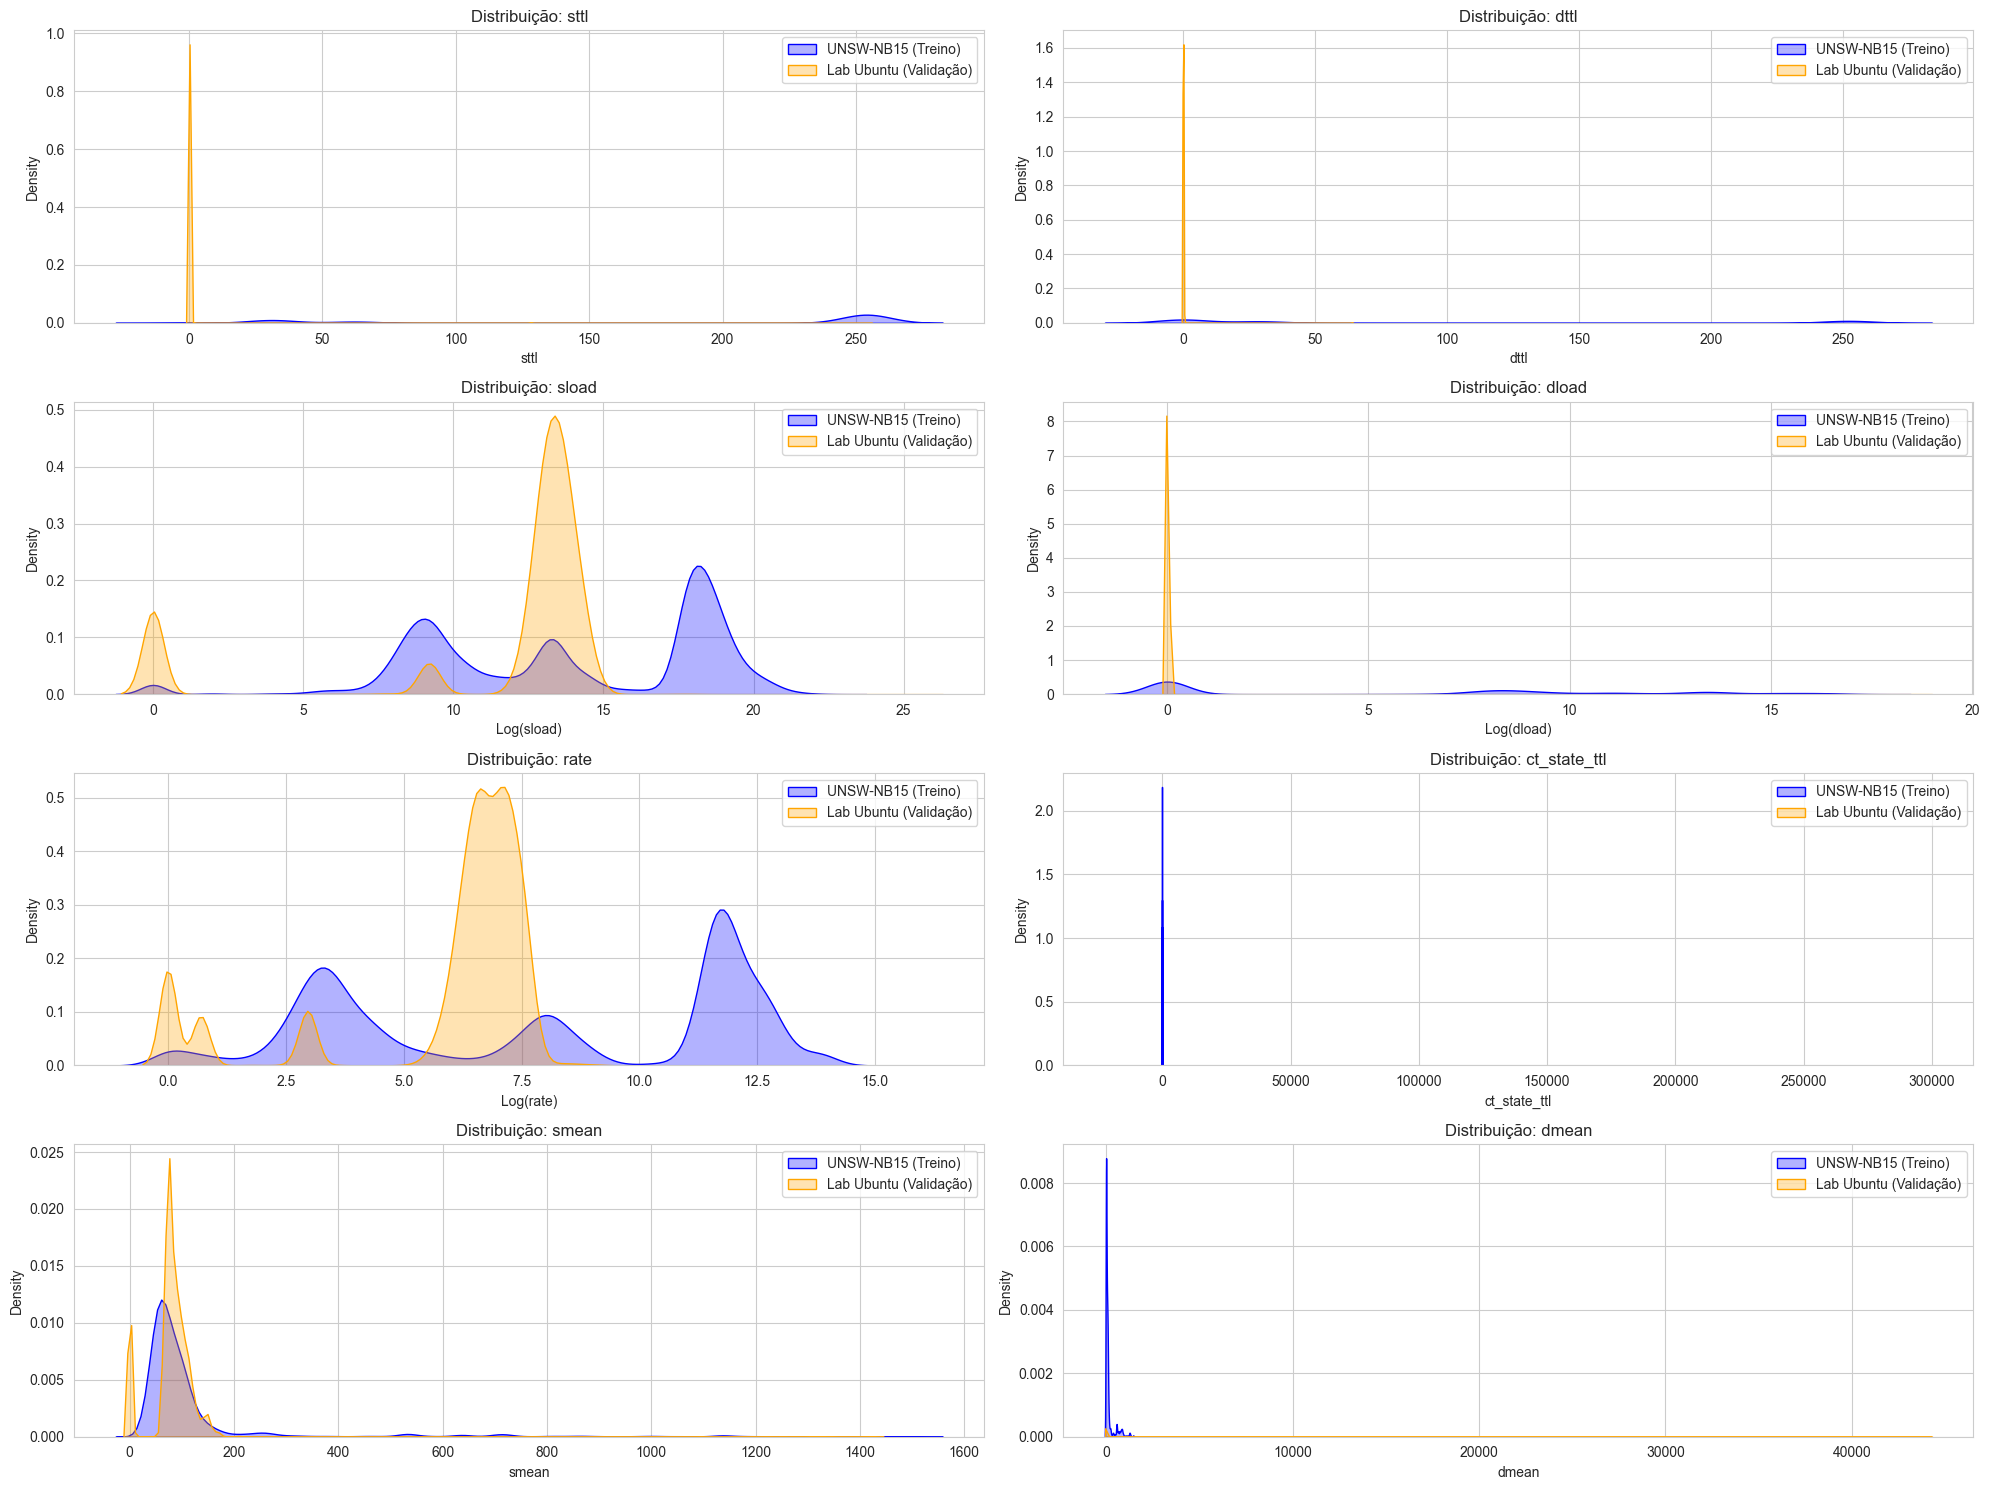


=== Comparação de Médias (Diferença Brutal indica Shift) ===
                Média UNSW      Média Lab  Diferença (%)
sttl          1.795470e+02       0.170375  -9.990511e+01
dttl          7.960957e+01       0.072945  -9.990837e+01
sload         7.345403e+07  935756.293753  -9.872607e+01
dload         6.712056e+05   29175.946955  -9.565320e+01
rate          9.540619e+04     932.276736  -9.902283e+01
ct_state_ttl  1.304179e+00  232251.033265   1.780812e+07
smean         1.367518e+02      79.549511  -4.182926e+01
dmean         1.241734e+02       4.084954  -9.671028e+01


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

# --- 1. Configuração de Caminhos ---
base_path = r'..\..\data'  # Ajuste se necessário para o seu ambiente
unsw_path = os.path.join(base_path, 'raw', 'UNSW-NB15', 'UNSW_NB15_training-set.csv')
lab_path = os.path.join(base_path, 'processed', 'ubuntu_server_dataset_final_argus.csv')

# --- 2. Carregamento dos Dados ---
print(f"Carregando UNSW-NB15 de: {unsw_path}")
try:
    df_unsw = pd.read_csv(unsw_path)
except FileNotFoundError:
    print(f"ERRO: Não encontrei o arquivo em {unsw_path}. Verifique o nome exato (ex: training-set.csv).")
    exit()

print(f"Carregando Lab Dataset de: {lab_path}")
df_lab = pd.read_csv(lab_path)

# --- 3. Seleção de Features Críticas ---
# Estas são features historicamente "fortes" em detecção de intrusão.
# Se elas divergirem, o modelo supervisionado quebra.
features_to_compare = [
    'sttl',          # Source Time To Live (Indica SO e proximidade)
    'dttl',          # Destination Time To Live
    'sload',         # Source Load (Velocidade de bits)
    'dload',         # Destination Load
    'rate',          # Taxa global de pacotes
    'ct_state_ttl',  # Feature complexa de correlação
    'smean',         # Tamanho médio do pacote (Source)
    'dmean'          # Tamanho médio do pacote (Destination)
]

# Filtra apenas colunas que existem em ambos (segurança contra typo)
common_features = [f for f in features_to_compare if f in df_unsw.columns and f in df_lab.columns]

print(f"Analisando as seguintes features comuns: {common_features}")

# --- 4. Plotagem Comparativa ---
# Configura o estilo
sns.set_style("whitegrid")
plt.figure(figsize=(20, 15))

for i, feature in enumerate(common_features):
    plt.subplot(4, 2, i + 1) # Grid 4x2
    
    # Truque: Usar Log Scale para features de rede (Load/Rate) pois a variação é exponencial
    use_log = feature in ['sload', 'dload', 'rate', 'dur']
    
    if use_log:
        # Adiciona +1 para evitar log(0)
        sns.kdeplot(np.log1p(df_unsw[feature]), label='UNSW-NB15 (Treino)', fill=True, color='blue', alpha=0.3)
        sns.kdeplot(np.log1p(df_lab[feature]), label='Lab Ubuntu (Validação)', fill=True, color='orange', alpha=0.3)
        plt.xlabel(f"Log({feature})")
    else:
        # Para TTL e contagens, plot normal
        sns.kdeplot(df_unsw[feature], label='UNSW-NB15 (Treino)', fill=True, color='blue', alpha=0.3)
        sns.kdeplot(df_lab[feature], label='Lab Ubuntu (Validação)', fill=True, color='orange', alpha=0.3)
        plt.xlabel(feature)
        
    plt.title(f"Distribuição: {feature}")
    plt.legend()

plt.tight_layout()
plt.show()

# --- 5. Análise Estatística Rápida (Médias) ---
print("\n=== Comparação de Médias (Diferença Brutal indica Shift) ===")
comparison = pd.DataFrame({
    'Média UNSW': df_unsw[common_features].mean(),
    'Média Lab': df_lab[common_features].mean()
})
comparison['Diferença (%)'] = ((comparison['Média Lab'] - comparison['Média UNSW']) / comparison['Média UNSW']) * 100
print(comparison)